# Preparación de datos - G6

In [3]:
# Liberias
import pandas as pd
import numpy as np
from unidecode import unidecode
from datetime import date
import rasterio
pd.set_option('display.max_columns', None)


#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

# librerias de modelado para regresion, lasso, ridge y elastic net
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

## 1. Base de datos principal

- Casos confirmados de Dengue y Dengue grave mensual 2007 a 2024 agregado por municipio de residencia, obtenida del SISPRO del ministerio de salud.
- Codigo divipola y coordenadas obtenidas de datos del DANE
https://www.datos.gov.co/Mapas-Nacionales/DIVIPOLA-C-digos-municipios-geolocalizados/vafm-j2df/about_data
- Datos climaticos mesnuales de temperatura y precipitación obtenidos de archivos historicos de WorldClim
https://www.worldclim.org/data/monthlywth.html


En esta primera sección se realiza la lectura y preparación inicial de las fuentes de datos, a continuación se lee la base de datos extraida del Sistema de Información de Salud y Protección social (SISPRO), estos datos son de consulta pública con usuario y contienen el consolidado de casos de Dengue y Dengue Grave para el aplicativo propuesto

In [ ]:
import pandas as pd
import numpy as np
import rasterio
from unidecode import unidecode
import calendar
from pathlib import Path

def normalize_str(s):
    """Utility to clean and normalize strings."""
    if not isinstance(s, str):
        return s
    return unidecode(str(s).split('-')[-1].strip().lower())

def load_db(f_path, sheet_name):
    """
    Carga y preprocesa los datos de dengue desde un archivo Excel.
    """
    # Usar converter para evitar problemas de tipos en columnas conocidas
    df = pd.read_excel(f_path, sheet_name=sheet_name)

    # 1. Clean column names
    df.columns = [normalize_str(c) for c in df.columns]
    df.rename(columns={'ano epidemiologico': 'year'}, inplace=True)

    # 2. Filter and Normalize strings
    df = df[~df['municipio'].str.contains('Sin Informacion', na=False)]
    df = df[df['pais'] != 'no definido']
    
    cols_to_fix = ['pais', 'departamento', 'municipio']
    for col in cols_to_fix:
        df[col] = df[col].apply(normalize_str)

    # 3. Reshape (Melt)
    df = df.melt(
        id_vars=['pais', 'departamento', 'municipio', 'year'],
        var_name='mes',
        value_name='casosconfirmados'
    )

    # 4. Map Months using standard library
    # Creates a map: {'Enero': 1, ...} assuming names are in Spanish as in the snippet
    month_names = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 
                   'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']
    mes_mapping = {name: i+1 for i, name in enumerate(month_names)}
    
    df['mes'] = df['mes'].map(mes_mapping)
    
    return df

def fill_location_timeseries(df):
    """
    Completa la serie temporal para cada combinación de Departamento y Municipio.
    Optimizado mediante el uso de un Reindex sobre un MultiIndex.
    """
    # 1. Ensure Date column
    if 'date' not in df.columns:
        df['date'] = pd.to_datetime(pd.DataFrame({
            'year': df['year'],
            'month': df['mes'],
            'day': 1
        }))
    
    # 2. Create the master grid of all possible dates and locations
    locations = df[['departamento', 'municipio']].drop_duplicates()
    all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
    
    # Generate Cartesian Product
    index_df = pd.MultiIndex.from_product(
        [locations['departamento'].unique(), locations['municipio'].unique(), all_dates],
        names=['departamento', 'municipio', 'date']
    ).to_frame(index=False)
    
    # Join with unique locations to filter only valid Dept-Muni pairs
    index_df = index_df.merge(locations, on=['departamento', 'municipio'])

    # 3. Merge original data into the grid
    df_complete = index_df.merge(df, on=['departamento', 'municipio', 'date'], how='left')
    
    # 4. Fill Year and Month for new rows
    df_complete['year'] = df_complete['date'].dt.year
    df_complete['mes'] = df_complete['date'].dt.month
    
    return df_complete.sort_values(['departamento', 'municipio', 'date']).reset_index(drop=True)

def add_worldclim(df: pd.DataFrame,
                  path_divipola: str = 'data/Listados_DIVIPOLA.xlsx',
                  sheet_divipola: str = 'Municipios',
                  elevation_files: dict = None,
                  climate_folders: dict = None):
    
    if elevation_files is None:
        elevation_files = {'elevacion': Path('data/worldclim/wc2.1_2.5m_elev/wc2.1_2.5m_elev.tif')}
    if climate_folders is None:
        climate_folders = {
            'tmin': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2020-2024')],
            'tmax': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2020-2024')],
            'prec': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2020-2024')]
        }

    # 1. Load and Clean DIVIPOLA
    divipola = pd.read_excel(path_divipola, sheet_name=sheet_divipola, skiprows=10, skipfooter=10)
    divipola.columns = ['cod_dept', 'departamento', 'cod_muni', 'municipio', 'tipo', 'longitud', 'latitud', 'nota']
    divipola = divipola[['departamento', 'municipio', 'cod_muni', 'tipo', 'longitud', 'latitud']]
    
    for col in ['departamento', 'municipio']:
        divipola[col] = divipola[col].apply(normalize_str)

    # 2. Municipality Name Harmonization (optimized via mapping)
    renamer = {
        'putumayo': {'leguizamo': 'puerto leguizamo'},
        'cauca': {'sotara': 'sotara paispamba', 'piendamo': 'piendamo - tunia', 'lopez': 'lopez de micay'},
        'valle del cauca': {'cali': 'santiago de cali'},
        # ... (rest of your mapping)
    }
    
    for dept, muni_map in renamer.items():
        mask = df['departamento'] == dept
        df.loc[mask, 'municipio'] = df.loc[mask, 'municipio'].replace(muni_map)

    # 3. Filter only valid locations
    df['loc_key'] = df['departamento'] + "_" + df['municipio']
    divipola['loc_key'] = divipola['departamento'] + "_" + divipola['municipio']
    
    df = df[df['loc_key'].isin(divipola['loc_key'])]
    df = df.merge(divipola.drop(columns=['departamento', 'municipio']), on='loc_key', how='left')

    # 4. Extract Elevation (Rasterio)
    unique_locs = df[['loc_key', 'longitud', 'latitud']].drop_duplicates()
    coords = list(zip(unique_locs['longitud'], unique_locs['latitud']))
    
    for var, path in elevation_files.items():
        with rasterio.open(path) as src:
            unique_locs[var] = [val[0] for val in src.sample(coords)]
            
    df = df.merge(unique_locs[['loc_key', 'elevacion']], on='loc_key', how='left')

    # 5. Extract Climate Data (Optimized: Open file once per group)
    climate_results = []
    
    # Prepare month strings for file naming
    df['mes_str'] = df['mes'].apply(lambda x: f"{int(x):02d}")
    
    groups = df.groupby(['year', 'mes_str'])
    for (year, month_str), group_df in groups:
        idx = 0 if year <= 2009 else (1 if year <= 2019 else 2)
        
        group_coords = list(zip(group_df['longitud'], group_df['latitud']))
        
        for var, folders in climate_folders.items():
            folder = folders[idx]
            # Assumes file structure based on your snippet logic
            file_name = f"{folder.name.rsplit('_', 1)[0]}_{year}-{month_str}.tif"
            file_path = folder / file_name
            
            if file_path.exists():
                with rasterio.open(file_path) as src:
                    values = [val[0] for val in src.sample(group_coords)]
                    for i, val in enumerate(values):
                        climate_results.append({
                            'loc_key': group_df.iloc[i]['loc_key'],
                            'year': year,
                            'mes': group_df.iloc[i]['mes'],
                            'variable': var,
                            'valor': val
                        })

    # 6. Pivot and Final Merge
    res_df = pd.DataFrame(climate_results)
    res_df = res_df.pivot_table(index=['loc_key', 'year', 'mes'], columns='variable', values='valor').reset_index()
    
    final_df = df.merge(res_df, on=['loc_key', 'year', 'mes'], how='left')
    final_df.rename(columns={'prec': 'Precipitacion', 'tmax': 'TempMax', 'tmin': 'TempMin'}, inplace=True)
    
    # Cleanup and Save
    final_df.drop(columns=['loc_key', 'mes_str'], inplace=True)
    
    return final_df



En la fase inicial, se identifica que los registros de SIVIGILA pueden presentar discontinuidades temporales o falta de reportes en meses específicos para ciertos municipios. Para resolver esto, la función load_db transforma los datos de un formato ancho (meses como columnas) a uno "largo" o tidy data, eliminando registros sin información. Posteriormente, mediante la función fill_location_timeseries, se genera una serie de tiempo continua para cada locación. Este proceso asegura que cada combinación de Departamento y Municipio cuente con una fila por cada mes dentro de su rango histórico, estandarizando las fechas al primer día de cada mes para facilitar el análisis posterior.

Para la georreferenciación, se integra la base de datos de la codificación DIVIPOLA del DANE. Esta fuente provee las coordenadas geográficas (latitud y longitud), el código oficial del municipio y su clasificación (municipio, isla o área no municipalizada). Estas variables son fundamentales para el reconocimiento espacial y la posterior vinculación de datos satelitales.

Sin embargo, para lograr una unión (merge) exitosa, es imperativo normalizar los nombres de las locaciones. Dado que los sistemas SIVIGILA y DANE suelen tener discrepancias ortográficas, se aplica un proceso de limpieza que incluye la conversión a minúsculas, la eliminación de caracteres especiales y acentos (mediante unidecode), y el uso de un diccionario de homologación (renamer). Este diccionario corrige nombres específicos (por ejemplo, transformando "Cali" en "Santiago de Cali" o "Leguizamo" en "Puerto Leguizamo") para garantizar la integridad referencial entre ambas fuentes.

Finalmente, se procede al enriquecimiento ambiental mediante el procesamiento de archivos ráster con la librería rasterio. En primer lugar, se extrae la elevación exacta de cada municipio basándose en sus coordenadas. Luego, se integran las variables climáticas de WorldClim (precipitación, temperatura máxima y mínima). Este paso es dinámico y preciso: el sistema identifica el archivo histórico correspondiente a cada registro según su año y mes, extrayendo los valores climáticos específicos para ese punto geográfico. El resultado final es una base de datos robusta, con continuidad temporal y variables biofísicas listas para modelos de predicción.

In [ ]:
df = load_db('data/Base_deng.xlsx', sheet_name='ocur')

df = fill_location_timeseries(df)

df = add_worldclim(df)

df.head()

df.to_csv('data/dengue_data_v2.csv', index=False, sep='|')


In [6]:
df = pd.read_csv('data/dengue_data_v2.csv', sep='|')
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin
0,amazonas,el encanto,2007-01-01,colombia,2007,1,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0
1,amazonas,el encanto,2007-02-01,colombia,2007,2,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0
2,amazonas,el encanto,2007-03-01,colombia,2007,3,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0
3,amazonas,el encanto,2007-04-01,colombia,2007,4,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228955,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0
228956,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0
228957,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0
228958,vichada,santa rosalia,2024-11-01,colombia,2024,11,NaN,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0


Se agregan datos del fenomeno del niño y de la niña con marcación categorica, este tipo de variable se debe agregar con rezagos temporales para la base definitiva, ya que la presencia continua de temeperaturas aumentadas o disminuidas son precisamente las que denotan que el fenomeno se acentue y se haga mención de su impacto a nivel nacional.

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,Precipitacion,TempMax,TempMin,fenomeno
0,amazonas,el encanto,2007-01-01,colombia,2007,1,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,391.1,31.0,22.0,nino_mod
1,amazonas,el encanto,2007-02-01,colombia,2007,2,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,144.6,32.0,23.0,neutral
2,amazonas,el encanto,2007-03-01,colombia,2007,3,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,568.9,30.0,22.0,neutral
3,amazonas,el encanto,2007-04-01,colombia,2007,4,NaN,91263,Área no municipalizada,-73.207114,-1.748060,158,538.6,30.0,22.0,neutral
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,392.1,29.0,22.0,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228955,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,255.6,31.0,22.0,neutral
228956,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,211.5,32.0,23.0,neutral
228957,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,238.2,32.0,23.0,neutral
228958,vichada,santa rosalia,2024-11-01,colombia,2024,11,NaN,99624,Municipio,-70.859499,5.136393,116,149.6,32.0,23.0,neutral


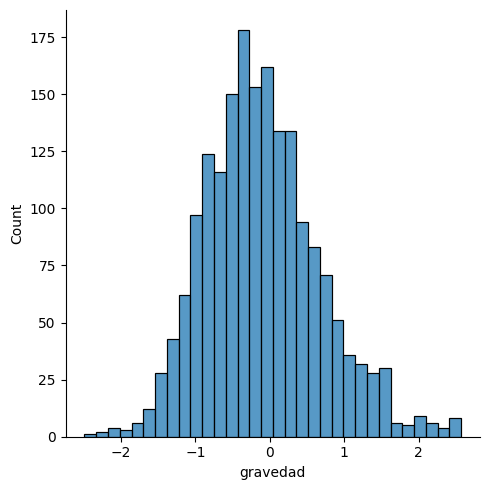

In [7]:
df_nino = pd.read_csv('data/nino34.long.anom.csv')
#* cambio en nobmres de columnas
df_nino.columns = ['date', 'gravedad']
#* se reemplazo el -99.99 por pd.na ya que es el dato faltante
df_nino['fenomeno'] = df_nino['gravedad'].apply(lambda x: pd.na if x==-99.99 else x)
#* agregar marcacion de la gravedad, si es >=1.5 nino_sev, 1.5>x>=0.5 es nino_moderado
df_nino['fenomeno'] = df_nino['gravedad'].apply(lambda x: 'nino_sev' if x >= 1.5 else
                                                          'nino_mod' if 1.5>x>=0.5 else
                                                          'neutral' if 0.5 > x >-0.5 else
                                                          'nina_mod' if -1.5<x<=-0.5 else
                                                          'nina_sev')

sns.displot(df_nino, x="gravedad")
df_nino.drop(columns='gravedad', inplace=True)


#* merge df and df_nino on date
df = df.merge(df_nino, on='date', how='left')

df

Se revisa la base de datos de trafico vehicular, particularmente se obtinene los datos relativos a trafico en peajes a lo largo del territorio nacional, los peajes manejas un id y un nombre especifios y tienen datos en ventanas de tiempo no homogeneas, se registra el trafico en un peaje particular para una ventana de 10 días en un mes y se pueden presentar otras ventanas en el mismo mes para el mismo peaje, parte del tratamiento de los datos invluye suavizar los datos de estas ventans a segmentos de datos diarios con el valor promedio del trafico para esos días, a partir de los valores diarios se obtiene el dato mensual de manera ordenada y teniendo en cuenta todo el trafico del peaje.

In [9]:
df_trafico = pd.read_csv('data/Tráfico_Vehicular_ANI_20260411.csv')
df_trafico['Peaje'] = df_trafico['Peaje'].apply(lambda x: unidecode(str(x).lower().strip()))
df_trafico.drop(columns=[i for i in df_trafico.columns if i not in ['Peaje','CantidadTrafico', 'CantidadExentos787', 'Desde','Hasta']], inplace=True)
df_trafico['CantidadTrafico'] = df_trafico['CantidadTrafico'].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df_trafico['CantidadExentos787'] = df_trafico['CantidadExentos787'].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df_trafico['TraficoTotal'] = df_trafico['CantidadTrafico'].astype(float) + df_trafico['CantidadExentos787'].astype(float)
df_trafico.drop(columns='CantidadTrafico', inplace=True)
df_trafico.drop(columns='CantidadExentos787', inplace=True)

df_trafico.head()


df_trafico['Desde'] = pd.to_datetime(df_trafico['Desde'], errors='coerce')
df_trafico['Hasta'] = pd.to_datetime(df_trafico['Hasta'], errors='coerce')

df_trafico['Desde'].min(), df_trafico['Hasta'].max()
# 2. Calculate the total days in each span (+1 to make it inclusive of start and end dates)
df_trafico['Dias'] = (df_trafico['Hasta'] - df_trafico['Desde']).dt.days + 1

# 3. Calculate the daily traffic for each specific row
df_trafico['TraficoDiario'] = df_trafico['TraficoTotal'] / df_trafico['Dias']

# 4. Generate a list of all individual dates between 'Desde' and 'Hasta' for each row
df_trafico['Fecha'] = df_trafico.apply(lambda row: pd.date_range(row['Desde'], row['Hasta']), axis=1)

# 5. Explode the DataFrame so every single day gets its own row with its 'TraficoDiario'
df_exploded = df_trafico.explode('Fecha')

# 6. Extract just the Year and Month from the exploded daily dates to group by
df_exploded['Mes_Anio'] = df_exploded['Fecha'].dt.to_period('M')

# 7. Group by 'Peaje' and the new 'Mes_Anio', summing up the daily traffic
df_monthly = df_exploded.groupby(['Peaje', 'Mes_Anio'])['TraficoDiario'].sum().reset_index()

# 8. Rename the aggregated column back to something meaningful
df_monthly.rename(columns={'TraficoDiario': 'TraficoTotalMensual'}, inplace=True)
meta_d_peajes = pd.read_csv('data/Peajes_.csv')
meta_d_peajes['nombrepeaje'] = meta_d_peajes['nombrepeaje'].apply(lambda x: unidecode(str(x).lower().strip()))

# * https://www.colombiaenmapas.gov.co/?u=0&t=19&servicio=100

from thefuzz import process, fuzz


def get_fuzzy_mapping(df_left, df_right, left_col, right_col, threshold=80):
    """
    Finds the best match from df_right for each entry in df_left.
    """
    # Get unique names from the right dataframe to speed up processing
    unique_right = df_right[right_col].unique()
    
    # Define a helper to find the best match
    def find_match(x):
        # process.extractOne returns (match, score)
        match, score = process.extractOne(x, unique_right, scorer=fuzz.token_sort_ratio)
        return match if score >= threshold else None

    def find_score(x):
        match, score = process.extractOne(x, unique_right, scorer=fuzz.token_sort_ratio)
        return score

    # Create mapping columns
    df_left['best_match'] = df_left[left_col].apply(find_match)
    df_left['similarity_score'] = df_left[left_col].apply(find_score)
    
    return df_left

# Execute mapping
mapped_df = get_fuzzy_mapping(df_trafico, meta_d_peajes, 'Peaje', 'nombrepeaje')

print("Mapping Results:")
print(set(list(zip(mapped_df['Peaje'], mapped_df['best_match'], mapped_df['similarity_score']))))


#* updating names in meta_d_peajes to match with df_trafico
matches = dict(zip(mapped_df['Peaje'], mapped_df['best_match']))
meta_d_peajes['nombrepeaje'] = meta_d_peajes['nombrepeaje'].replace(matches)

meta_d_peajes.drop(columns=[i for i in meta_d_peajes.columns if i not in ['nombrepeaje', 'X', 'Y']], inplace=True)
meta_d_peajes.rename(columns={'nombrepeaje': 'Peaje', 'X':'longitud','Y':'latitud'}, inplace=True)

df_monthly = df_monthly.merge(meta_d_peajes, on='Peaje', how='left')
df_monthly.head()

df_monthly.to_csv('data/df_monthly_trafico_peajes.csv', index=False, sep='|')

C:\Users\sergi\AppData\Local\Temp\ipykernel_12540\385718182.py:1: DtypeWarning: Columns (0: CantidadTrafico) have mixed types. Specify dtype option on import or set low_memory=False.
  df_trafico = pd.read_csv('data/Tráfico_Vehicular_ANI_20260411.csv')
C:\Users\sergi\AppData\Local\Temp\ipykernel_12540\385718182.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_trafico['Desde'] = pd.to_datetime(df_trafico['Desde'], errors='coerce')
C:\Users\sergi\AppData\Local\Temp\ipykernel_12540\385718182.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_trafico['Hasta'] = pd.to_datetime(df_trafico['Hasta'], errors='coerce')


Mapping Results:
{('rio grande', nan, 60), ('supia', 'supia', 100), ('turbaco', 'turbaco', 100), ('arroyo de piedra', nan, 74), ('purgatorio', 'purgatorio', 100), ('fusca', 'fusca', 100), ('caiquero', 'caiqueros', 94), ('el pata', 'el pata', 100), ('chinauta', 'chinauta', 100), ('puente quetame', nan, 54), ('caimanera', 'caimanera', 100), ('san diego', 'san diego', 100), ('armero', 'armero', 100), ('tucurinca', 'tucunica', 82), ('honda', 'honda', 100), ('curiti', nan, 67), ('calamar', 'calamar', 100), ('cirilo', 'cirilo', 100), ('puente amarillo', 'puente amarillo', 100), ('flandes', 'flandes', 100), ('los garzones 1', 'los garzones 1', 100), ('acapulco', 'acapulco', 100), ('marahuaco', 'marahuaco', 100), ('los curos', 'los curos', 100), ('oiba', 'oiba', 100), ('rionegro', 'rionegro', 100), ('cambao', 'cambao', 100), ('galapa', 'galapa', 100), ('circasia', 'circasia', 100), ('los cauchos', 'los cauchos', 100), ('santagueda', 'santagueda', 100), ('juan mina', 'juan mina', 100), ('el eba

In [15]:
# correspondencia peajes - municipios
#* a partir de latitud y longitud, asignar el peaje al municipio más cercano
municipios_presentes = df[['departamento', 'municipio', 'longitud', 'latitud']].drop_duplicates()
peajes_presentes = df_monthly[['Peaje', 'longitud', 'latitud']].drop_duplicates()
peajes_presentes.dropna(inplace=True)

#* funcion para calcular distancia entre dos puntos geograficos
from geopy.distance import geodesic
def find_closest_peaje(muni_row, peajes_df):
    #* return at most a list of 3 peajes 1st is closes in radius of 25km,
    #* 2nd is closest in radius of 50km, 3rd is closest in radius of 100km
    #* if no peaje is found for a radius fill the list wiht a None in that position
    closest_peajes = [None, None, None]
    for _, peaje_row in peajes_df.iterrows():
        distance = geodesic((muni_row['latitud'], muni_row['longitud']), (peaje_row['latitud'], peaje_row['longitud'])).km
        if distance <= 25 and closest_peajes[0] is None:
            closest_peajes[0] = peaje_row['Peaje']
        elif distance <= 50 and closest_peajes[1] is None:
            closest_peajes[1] = peaje_row['Peaje']
        elif distance <= 75 and closest_peajes[2] is None:
            closest_peajes[2] = peaje_row['Peaje']
    return closest_peajes

#* aplicar la funcion a cada municipio
municipios_presentes[['Peaje_25km', 'Peaje_50km', 'Peaje_100km']] = municipios_presentes.apply(lambda row: find_closest_peaje(row, peajes_presentes), axis=1, result_type='expand')

municipios_presentes.head()
    




,departamento,municipio,longitud,latitud,Peaje_25km,Peaje_50km,Peaje_100km
0,amazonas,el encanto,-73.207114,-1.748060,None,None,None
216,amazonas,la chorrera,-72.791889,-1.442617,None,None,None
432,amazonas,la pedrera,-69.585499,-1.320301,None,None,None
648,amazonas,la victoria,-71.223208,0.054936,None,None,None
864,amazonas,leticia,-69.941721,-4.198950,None,None,None


In [16]:
municipios_presentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1060 entries, 0 to 228744
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   departamento  1060 non-null   str    
 1   municipio     1060 non-null   str    
 2   longitud      1060 non-null   float64
 3   latitud       1060 non-null   float64
 4   Peaje_25km    465 non-null    object 
 5   Peaje_50km    731 non-null    object 
 6   Peaje_100km   843 non-null    object 
dtypes: float64(2), object(3), str(2)
memory usage: 76.1+ KB


In [19]:
df_monthly['Mes_Anio'].min(), df_monthly['Mes_Anio'].max()

(Period('2014-01', 'M'), Period('2025-06', 'M'))

Aun no se define propiamente el uso de los datos de trafico vehicular ya que la relación del trafico no se conoce de antemano hasta que punto se puede estimar o desestimar por la distancia del peaje a las coordenadas del municipio. Además si la serie de tiempo vien fragmentada es necesario otro ajuste de imputación, sin mencionar que el flujo de trafico es generalizado, lo que es bueno para anticipar el uso de la vía pero no distingue propiamente el sentido del flujo ni si durante el periodo de evaluación este flujo no es simetrico.

## 2. Análisis exploratorio de datos

In [ ]:
df = pd.read_csv('data/dengue_data_v2.csv', sep='|')

df.drop(columns=['CodigoMunicipio'], inplace=True)
cols_t_str = ['Year', 'Mes']
for col in cols_t_str:
    df[col] = df[col].apply(lambda x: str(x).zfill(2) if len(str(x)) == 1 else str(x))
df.head()


In [ ]:
df.info()

In [ ]:
df[[ 'CasosConfirmados', 'Elevacion', 'Precipitacion', 'TempMax', 'TempMin']].describe()

In [ ]:
df[[ 'CasosConfirmados', 'Elevacion', 'Precipitacion', 'TempMax', 'TempMin']].corr()

In [ ]:
int(df[(df['Year']=='2024') & (df['Mes']=='05')]['CasosConfirmados'].sum())

In [ ]:
# departamentos con mas casos confirmados y porcentaje del total
total_casos = int(df['CasosConfirmados'].sum())
df_departamentos = df[['Departamento', 'CasosConfirmados']].groupby('Departamento').sum().reset_index(drop=False)
df_departamentos['CasosConfirmados'] = df_departamentos['CasosConfirmados'].astype(int)
df_departamentos['Porcentaje'] = (df_departamentos['CasosConfirmados'] / total_casos) * 100
df_departamentos.sort_values('CasosConfirmados', ascending=False).head(25).reset_index(drop=True)

In [ ]:
#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

In [ ]:
# funciones para analisis exploratorio y visualizacion de datos

#* Análisis de correlación
def plot_correlation_map( df ):
    corr = df.corr()
    _ , ax = plt.subplots( figsize =( 12 , 10 ) )
    cmap = sns.diverging_palette( 220 , 10 , as_cmap = True )
    _ = sns.heatmap(
        corr, 
        cmap = cmap,
        square=True, 
        cbar_kws={ 'shrink' : .9 }, 
        ax=ax, 
        annot = True, 
        annot_kws = { 'fontsize' : 12 }
    )

def frecuencia_mensual_con_umbral(df, umbral=5000):
    #* frecuencia por meses y años en cundinamarca con años separados en diferentes subplots
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    df_agrupado = df_agrupado.sort_values(by=['Year', 'Mes'])

    # 2. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 3. Creación de la cuadrícula
    g = sns.FacetGrid(df_agrupado, col="Year", col_wrap=4, height=3, aspect=1.5, sharex=False, sharey=False)

    # 4. Gráfico principal (Línea de casos)
    g.map(sns.lineplot, "Mes", "CasosConfirmados", marker="o")

    # umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label="Umbral 5000")

    # 5. Ajustes finales
    g.set_axis_labels("Mes", "Total Casos")
    g.set_titles(col_template="Año {col_name}")
    g.fig.suptitle("Comportamiento Mensual vs Umbral de Referencia", y=1.02)

    g.add_legend()

    plt.show()

def frecuencia_mensual_con_umbral_v2(df, umbral=5000, anos_por_subplot=1):
    """
    Genera gráficos de línea para casos confirmados.
    
    Args:
        df: DataFrame con columnas 'Year', 'Mes', 'CasosConfirmados'.
        umbral: Valor para la línea horizontal de referencia.
        anos_por_subplot: Cantidad de años continuos a mostrar en cada gráfica (ej. 2 para pares de años).
    """
    
    # 1. Agrupación inicial
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    
    # 2. Crear columna 'Fecha' para tener un Eje X continuo
    # Es vital convertir a datetime para que al graficar 2 o 3 años seguidos, 
    # la línea continúe cronológicamente y no se superpongan los meses.
    df_agrupado['Fecha'] = pd.to_datetime(
        df_agrupado['Year'].astype(str) + '-' + df_agrupado['Mes'].astype(str) + '-01'
    )
    df_agrupado = df_agrupado.sort_values('Fecha')

    # 3. Definir los bloques de años (Periodos)
    min_year = df_agrupado['Year'].min()
    
    # Calculamos un índice de bloque: (AñoActual - AñoMinimo) // N
    df_agrupado['Bloque_Indice'] = (df_agrupado['Year'] - min_year) // anos_por_subplot
    
    # Generamos etiquetas legibles para los títulos (Ej: "2007-2008")
    def generar_etiqueta(row):
        inicio = min_year + (row['Bloque_Indice'] * anos_por_subplot)
        fin = inicio + anos_por_subplot - 1
        if anos_por_subplot == 1:
            return str(inicio)
        return f"{inicio} - {fin}"

    df_agrupado['Periodo'] = df_agrupado.apply(generar_etiqueta, axis=1)

    # 4. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 5. Creación de la cuadrícula
    # Usamos 'Periodo' en col, y aumentamos el 'aspect' (ancho) para que quepan mejor las fechas
    g = sns.FacetGrid(df_agrupado, col="Periodo", col_wrap=3, height=3.5, aspect=2, sharex=False, sharey=False)

    # 6. Gráfico principal
    # Usamos 'Fecha' en el eje X en lugar de 'Mes'
    g.map(sns.lineplot, "Fecha", "CasosConfirmados", marker="o")

    # Umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label=f"Umbral {umbral}")

    # 7. Ajustes finales
    g.set_axis_labels("Fecha", "Total Casos")
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f"Comportamiento de Casos ({anos_por_subplot} años por gráfica)", y=1.02)

    # Rotación de fechas en el eje X para evitar solapamiento
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')

    g.add_legend()
    plt.show()



In [ ]:
#* Casos confirmados por año
plt.figure(figsize=(15,8))
for col in ['Year', 'Mes']:
    df[col] = df[col].astype(int)
#* plotting but making year to not display decimal points in x axis
sns.lineplot(data=df, x='Year', y='CasosConfirmados', estimator='sum', marker='o')
plt.xticks(df['Year'].unique())  # Asegura que solo se muestren los años presentes en el DataFrame

# remove borders right and top
sns.despine()
plt.title('Casos confirmados de dengue por año en Colombia')

In [ ]:
df['Mes'] = df['Mes'].apply(lambda x: int(x))
frecuencia_mensual_con_umbral(df)

In [ ]:
#* temperaturas y precipitacion promedio por año
cols = ['Precipitacion','TempMax','TempMin']
df['Year'] = df['Year'].astype(int)
for col in cols:
    plt.figure(figsize=(10, 6))
    
    # 1. Tu gráfica original (Línea de promedios anuales)
    sns.lineplot(data=df, x='Year', y=col, estimator='mean', label='Promedio Anual')
    
    # 2. Preparar datos para la tendencia (Agrupamos por año para obtener el promedio)
    # Esto es necesario porque lineplot agrega internamente, pero para calcular la tendencia
    # necesitamos los puntos exactos (x, y) de esos promedios.
    df_trend = df.groupby('Year')[col].mean().reset_index()
    
    # 3. Graficar la línea de tendencia usando regplot
    # scatter=False evita que pinte los puntos de nuevo, solo queremos la línea
    # ci=None quita la sombra del intervalo de confianza (opcional, puedes dejarlo si prefieres)
    sns.regplot(data=df_trend, x='Year', y=col, scatter=False, color='red', line_kws={'linestyle':'--'}, label='Tendencia Lineal', ci=None)
    
    plt.title(f'{col} promedio por año en Colombia')
    plt.xticks(df['Year'].unique())  # Asegura que solo se muestren los años presentes en el DataFrame
    plt.legend()
    sns.despine()
    plt.show()
    



In [ ]:
df

In [ ]:
# crear df con rezago de temperaturas y precipitacion
df_lag = df.copy()

df_lag.sort_values(['Departamento', 'Municipio', 'Year', 'Mes'], inplace=True)

df_lag.reset_index(drop=True, inplace=True)
df_lag

In [ ]:
df_lag['Precipitacion_Lag1'] = df_lag.groupby(['Departamento', 'Municipio'])['Precipitacion'].shift(1)
df_lag['Precipitacion_Lag2'] = df_lag.groupby(['Departamento', 'Municipio'])['Precipitacion'].shift(2)
df_lag['Precipitacion_Lag3'] = df_lag.groupby(['Departamento', 'Municipio'])['Precipitacion'].shift(3)
df_lag['TempMax_Lag1'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMax'].shift(1)
df_lag['TempMax_Lag2'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMax'].shift(2)
df_lag['TempMax_Lag3'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMax'].shift(3)
df_lag['TempMin_Lag1'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMin'].shift(1)
df_lag['TempMin_Lag2'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMin'].shift(2)
df_lag['TempMin_Lag3'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMin'].shift(3)



In [ ]:
df_lag

In [ ]:
#* drop row if a Lag column has nan value
lag_cols = [col for col in df_lag.columns if 'Lag' in col]
df_lag.dropna(subset=lag_cols, inplace=True)
df_lag.reset_index(drop=True, inplace=True)
df_lag.head()

In [ ]:
df_lag.shape

In [ ]:
df_lag.to_csv('data/dengue_data_v3.csv', index=False, sep='|')

In [ ]:
# df_lag agrupado por mes en un año especifico
df_lag_2 = df_lag[df_lag['Year'] == 2023]
df_lag_2 = df_lag_2.groupby(['Year', 'Mes'])[['CasosConfirmados',
                                   'Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1',
                                   'Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2',
                                   'Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']].agg({'CasosConfirmados': 'sum',
                                                                                              'Precipitacion_Lag1': 'mean', 'TempMax_Lag1': 'mean', 'TempMin_Lag1': 'mean',
                                                                                              'Precipitacion_Lag2': 'mean', 'TempMax_Lag2': 'mean', 'TempMin_Lag2': 'mean',
                                                                                              'Precipitacion_Lag3': 'mean', 'TempMax_Lag3': 'mean', 'TempMin_Lag3': 'mean'}).reset_index(drop=False)

In [ ]:
# normalizar variables no temporales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_lag_2[['Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1']])
df_lag_2[['Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2']])
df_lag_2[['Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']])

df_lag_2['CasosConfirmados'] = scaler.fit_transform(df_lag_2[['CasosConfirmados']])

df_lag_2

In [ ]:
# line graph of CasosConfirmados vs Precipitacion_Lag1, TempMax_Lag1 and TempMin_Lag1
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='Mes', y='CasosConfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='Mes', y='Precipitacion_Lag1', 
             marker='o', label='Precipitación Lag 1', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMax_Lag1', 
             marker='o', label='TempMax Lag 1', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMin_Lag1', 
             marker='o', label='TempMin Lag 1', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 1)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()



In [ ]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='Mes', y='CasosConfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='Mes', y='Precipitacion_Lag2', 
             marker='o', label='Precipitación Lag 2', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMax_Lag2', 
             marker='o', label='TempMax Lag 2', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMin_Lag2', 
             marker='o', label='TempMin Lag 2', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 2)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

In [ ]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='Mes', y='CasosConfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='Mes', y='Precipitacion_Lag3', 
             marker='o', label='Precipitación Lag 3', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMax_Lag3', 
             marker='o', label='TempMax Lag 3', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMin_Lag3', 
             marker='o', label='TempMin Lag 3', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 3)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

## 3. Modelado de datos

In [ ]:
df = pd.read_csv('data/dengue_data_v3.csv', sep='|')
df

In [ ]:
"---".join(list(df['Departamento'].unique()))

In [ ]:
# verificacion de cuantos municipios por departamento tienen una serie completa de datos (2007-2024) para cada mes
# depts = ['valle del cauca','santander','tolima', 'antioquia', 'meta', 'huila','norte de santander','atlantico','bolivar','cesar']
# depts = ['cundinamarca', 'boyaca']
depts = df['Departamento'].unique()
depts_full = []
depts_15 = []
depts_12 = []
depts_10 = []
for dept in depts:
# dept = 'antioquia'
    df_dept = df[df['Departamento'] == dept]
    df_dept['Year'] = df_dept['Year'].astype(int)

    full = [] #18*12
    al_menos_15 = [] #15*12
    al_menos_12 = [] #12*12
    al_menos_10 = [] #10*12
    al_menos_5 =[] #5*12
    menos_de_5 = [] #menos de 5*12
    for muni in df_dept['Municipio'].unique():
        df_muni = df_dept[df_dept['Municipio'] == muni]
        count = df_muni.groupby(['Year', 'Mes']).size().reset_index(name='Count')
        # count if not nan values in CasosConfirmados column
        count = df_muni[~df_muni['CasosConfirmados'].isna()].groupby(['Year', 'Mes']).size().reset_index(name='Count')
        count_total = count['Count'].sum()
        if count_total == (18*12)-3: #* 3 meses faltantes por rezagos completos
            full.append(muni)
        elif count_total >= 15*12:
            al_menos_15.append(muni)
        elif count_total >= 12*12:
            al_menos_12.append(muni)
        elif count_total >= 10*12:
            al_menos_10.append(muni)
        elif count_total >= 5*12:
            al_menos_5.append(muni)
        else:
            menos_de_5.append(muni)
        del df_muni, count
    #* si el departamente tiene un 80% o mas de sus municipios con serie completa de datos, agregarlo a la lista de departamentos con buena cobertura
    if len(full)/len(df_dept['Municipio'].unique()) >= 0.8:
        depts_full.append(dept)
    if len(al_menos_15+full)/len(df_dept['Municipio'].unique()) >= 0.8:
        depts_15.append(dept)
    if len(al_menos_12+al_menos_15+full)/len(df_dept['Municipio'].unique()) >= 0.8:
        depts_12.append(dept)
    if len(al_menos_10+al_menos_12+al_menos_15+full)/len(df_dept['Municipio'].unique()) >= 0.8:
        depts_10.append(dept)

    print(f"Municipios del {dept} con serie completa de datos (18 años): {len(full)/len(df_dept['Municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 15 años de datos: {len(al_menos_15)/len(df_dept['Municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 12 años de datos: {len(al_menos_12)/len(df_dept['Municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 10 años de datos: {len(al_menos_10)/len(df_dept['Municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 5 años de datos: {len(al_menos_5)/len(df_dept['Municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con menos de 5 años de datos: {len(menos_de_5)/len(df_dept['Municipio'].unique())*100:.2f}%")
    print("\n")

In [ ]:
# depts_full
# depts_15
# depts_12
depts_10

In [ ]:
len(depts_10)

In [ ]:
discontinuos = {}
for dept in depts_10:
    df_dept = df[df['Departamento'] == dept]
    for muni in df_dept['Municipio'].unique():
        años = []
        df_muni = df_dept[df_dept['Municipio'] == muni]    
        #* tomamos el minimo año y el maximo por en el municipio para identificar si hay saltos de meses o años en la serie de datos
        min_year = df_muni['Year'].min()
        max_year = df_muni['Year'].max()
        #* identificar municipios que tienen salto de mes en algn año
        for year in range(min_year, max_year+1):
            df_year = df_muni[df_muni['Year'] == year]
            #* si el año es el primero de la serie, esperamos que no tenga los primeros 3 meses por los rezagos, pero si el año es el ultimo de la serie, esperamos que no tenga los ultimos 3 meses por los rezagos, en caso contrario, esperamos que tenga los 12 meses
            meses_esperados = set(range(1,13)) if year > min_year else set(range(4,13))
            #* meses presentes son sin nan en CasosConfirmados
            # meses_presentes = set(df_year['Mes'].unique())
            meses_presentes = set(df_year[~df_year['CasosConfirmados'].isna()]['Mes'].unique())
            if meses_esperados != meses_presentes:
                #* si faltan todos los meses 
                if len(meses_presentes) == 0:
                    print(f"El municipio {muni} en el departamento {dept} no tiene datos para el año {year}.")
                else:
                    print(f"El municipio {muni} en el departamento {dept} tiene salto de meses en el año {year}. Meses faltantes: {meses_esperados-meses_presentes}")
                años.append(year)
        if len(años) > 0:
            if dept not in discontinuos:
                discontinuos[f"{dept}"] = {f"{muni}": años}
            else:
                discontinuos[f"{dept}"][f"{muni}"] = años

In [ ]:
# Calcular perdida de datos por departamento considerando los municipios con saltos
perdida_por_dept = {}
for dept, munis in discontinuos.items():
    total_municipios = len(df[df['Departamento'] == dept]['Municipio'].unique())
    municipios_con_saltos = len(munis)
    perdida_por_dept[dept] = (municipios_con_saltos / total_municipios) * 100
    print(f"Departamento: {dept}, Municipios con saltos: {municipios_con_saltos}/{total_municipios} ({perdida_por_dept[dept]:.2f}%)")

In [ ]:
# 1. Safer way to identify variables (avoiding metadata/time columns)
exclude_cols = ['Departamento', 'Municipio', 'Year', 'Mes', 'TipoMunicipio', 'Longitud', 'Latitud', 'CodigoMunicipio', 'Date']
vars_to_impute = [c for c in df.columns if c not in exclude_cols]

for dept in depts_10:
    df_dept = df[df['Departamento'] == dept]
    for muni in df_dept['Municipio'].unique():
        # Get a slice for the current municipality
        df_muni = df_dept[df_dept['Municipio'] == muni]
        
        # Get basic info
        min_year = df_muni['Year'].min()
        
        # 2. Identify indices where CasosConfirmados is NaN 
        # (Assuming these rows were created by your grid completion step)
        nan_indices = df_muni[df_muni['CasosConfirmados'].isna()].index
        
        for idx in nan_indices:
            # Retrieve the row data from the main DF using the index
            row = df.loc[idx]
            year = row['Year']
            mes = row['Mes']
            
            # Logic check: Only impute if it meets your "expected months" criteria 
            # (e.g., month >= 4 if it's the first year)
            if year == min_year and mes < 4:
                continue
                
            # 3. Filter historical data for the same month across previous years
            # We ensure we only use rows that HAVE data (notna) to calculate the mean
            df_hist = df_muni[
                (df_muni['Year'] < year) & 
                (df_muni['Mes'] == mes) & 
                (df_muni['CasosConfirmados'].notna())
            ]
            
            if len(df_hist) >= 4:
                # 4. Impute values directly into the existing row in the main 'df'
                for v in vars_to_impute:
                    mean_val = df_hist[v].astype(float).mean()
                    df.loc[idx, v] = mean_val
                
                print(f"Imputado: {muni} ({dept}) para {year}-{mes} usando {len(df_hist)} años previos.")
            else:
                print(f"No se pudo imputar: {muni} ({dept}) para {year}-{mes} (Datos insuficientes: {len(df_hist)})")


In [ ]:
# vars = [i for i in df.columns][7:]
# for dept in depts_10:
#     df_dept = df[df['Departamento'] == dept]
#     for muni in df_dept['Municipio'].unique():
#         years = []
#         df_muni = df_dept[df_dept['Municipio'] == muni]    
#         lon = df_muni['Longitud'].iloc[0]
#         lat = df_muni['Latitud'].iloc[0]
#         tip_muni = df_muni['TipoMunicipio'].iloc[0]
#         #* tomamos el minimo año y el maximo por en el municipio para identificar si hay saltos de meses o años en la serie de datos
#         min_year = df_muni['Year'].min()
#         max_year = df_muni['Year'].max()
#         #* identificar municipios que tienen salto de mes en algn año
#         for year in range(min_year, max_year+1):
#             df_year = df_muni[df_muni['Year'] == year]
#             #* si el año es el primero de la serie, esperamos que no tenga los primeros 3 meses por los rezagos, pero si el año es el ultimo de la serie, esperamos que no tenga los ultimos 3 meses por los rezagos, en caso contrario, esperamos que tenga los 12 meses
#             meses_esperados = set(range(1,13)) if year > min_year else set(range(4,13))
#             meses_presentes = set(df_year['Mes'].unique())
#             if meses_esperados != meses_presentes:
#                 #* imputar con promedio de años anteriores para cada mes, siempre que el promedio sea de al menos 4 años
#                 for mes in meses_esperados - meses_presentes:
#                     df_meses_anteriores = df_muni[(df_muni['Year'] < year) & (df_muni['Mes'] == mes)]
#                     if len(df_meses_anteriores) >= 4:
#                         vars_means = {}
#                         for v in vars:
#                             df_meses_anteriores[v] = df_meses_anteriores[v].astype(float)
#                             #* Metodo de imputacion: promedio años anteriores
#                             vars_means[v] = df_meses_anteriores[v].mean()
#                         new_row = {'Departamento': dept, 'Municipio': muni,'TipoMunicipio': tip_muni, 'Longitud': lon, 'Latitud': lat, 'Year': year, 'Mes': mes}
#                         for v in vars:
#                             new_row[v] = vars_means[v]
#                         df.loc[len(df)] = new_row
#                         print(f"Se imputo para el municipio {muni} en el departamento {dept} para el año {year} y mes {mes} con promedio de {len(df_meses_anteriores)} años anteriores")
#                     else:
#                         print(f"No se pudo imputar para el municipio {muni} en el departamento {dept} para el año {year} y mes {mes} por falta de datos anteriores")
                

In [ ]:
discontinuos2 = {}
for dept in depts_10:
    df_dept = df[df['Departamento'] == dept]
    for muni in df_dept['Municipio'].unique():
        años = []
        df_muni = df_dept[df_dept['Municipio'] == muni]    
        #* tomamos el minimo año y el maximo por en el municipio para identificar si hay saltos de meses o años en la serie de datos
        min_year = df_muni['Year'].min()
        max_year = df_muni['Year'].max()
        #* identificar municipios que tienen salto de mes en algn año
        for year in range(min_year, max_year+1):
            df_year = df_muni[df_muni['Year'] == year]
            #* si el año es el primero de la serie, esperamos que no tenga los primeros 3 meses por los rezagos, pero si el año es el ultimo de la serie, esperamos que no tenga los ultimos 3 meses por los rezagos, en caso contrario, esperamos que tenga los 12 meses
            meses_esperados = set(range(1,13)) if year > min_year else set(range(4,13))
            meses_presentes = set(df_year['Mes'].unique())
            if meses_esperados != meses_presentes:
                print(f"El municipio {muni} en el departamento {dept} tiene salto de meses en el año {year}. Meses faltantes: {meses_esperados-meses_presentes}")
                años.append(year)
        if len(años) > 0:
            if dept not in discontinuos2:
                discontinuos2[f"{dept}"] = {f"{muni}": años}
            else:
                discontinuos2[f"{dept}"][f"{muni}"] = años

In [ ]:
discontinuos2

In [ ]:
perdida_por_dept2 = {}
for dept, munis in discontinuos2.items():
    total_municipios = len(df[df['Departamento'] == dept]['Municipio'].unique())
    municipios_con_saltos = len(munis)
    perdida_por_dept2[dept] = (municipios_con_saltos / total_municipios) * 100
    print(f"Departamento: {dept}, Municipios con saltos: {municipios_con_saltos}/{total_municipios} ({perdida_por_dept2[dept]:.2f}%)")

In [ ]:
df

In [ ]:
df.info()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos Scikit-Learn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# df donde se descartan los identificadores de departamento y municipio y se opera solo con latitud y longitud
df_coords = df.drop(columns=['Departamento', 'Municipio', 'TipoMunicipio'])

df_coords

In [ ]:
# make dummies for Year and Mes
df_coords = pd.get_dummies(df_coords, columns=['Year', 'Mes'], drop_first=True, dtype=int)
df_coords.head()

In [ ]:
# scale variables no binarias
scaler = StandardScaler()
vars_to_scale = [i for i in df_coords.columns if i not in ['Longitud', 'Latitud', 'CasosConfirmados'] and not i.startswith('Year_') and not i.startswith('Mes_')]
df_coords[vars_to_scale] = scaler.fit_transform(df_coords[vars_to_scale])
df_coords.head()

In [ ]:
X, y = df_coords.drop(columns=['CasosConfirmados']), df_coords['CasosConfirmados']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def evaluate_model(y_true, y_pred):
    """Calcula y retorna un diccionario con las métricas de regresión."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R²": r2}

results = {}


print("Entrenando modelos de Regresión...")
sklearn_models = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR (Kernel RBF)": SVR(kernel='rbf')
}

for name, model in sklearn_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = evaluate_model(y_test, preds)

In [ ]:
results

In [ ]:
for dept in depts_10:
    df_dept = df[df['Departamento'] == dept]
    df_dept['Year'] = df_dept['Year'].astype(str)
    df_dept.sort_values(['Year', 'Mes'], inplace=True)
    plt.figure(figsize=(15,8))
    sns.lineplot(data=df_dept, x='Year', y='CasosConfirmados', estimator='sum', marker='o')
    # remove borders right and top
    sns.despine()
    plt.title(f'Casos confirmados de dengue por año en {dept}')
    plt.show()
    del df_dept

In [ ]:
# definir año minimo estandarizado

for dept in depts_10:
    df_dept = df[df['Departamento'] == dept]
    df_dept['Year'] = df_dept['Year'].astype(int)
    min_year = df_dept['Year'].min()
    print(f"Año mínimo para {dept}: {min_year}")

In [ ]:
# df donde se descartan los identificadores de departamento y municipio y se opera solo con latitud y longitud
df_coords = df.drop(columns=['Departamento', 'Municipio', 'TipoMunicipio'])

df_coords

In [ ]:
# df donde se descartan coordenadas y se opera solo con departamento y municipio codificados como variables dummy
df_cat = df.drop(columns=['Longitud', 'Latitud'])
df_cat['Year'] = df_cat['Year'].astype(str)
df_cat['Mes'] = df_cat['Mes'].astype(str)
# cargar encoders para departamento, municipio y tipo municipio
df_cat = pd.get_dummies(df_cat, columns=['Departamento', 'Municipio', 'TipoMunicipio','Year', 'Mes'], drop_first=True, dtype=int)
df_cat

